# Agent 03 Trades Ticks Monitor and Granular Review

Este notebook separa dos capas:

- `203`: resumen operativo del run y cobertura esperada vs encontrada.
- `206`: anal?tica granular visual por `ticker/date/status`, con foco en `DOWNLOADED_EMPTY`, `SOFT_FAIL`, `HARD_FAIL` y casos sin file.


In [11]:
from pathlib import Path

RUN_ID = 'trades_ticks_prod_2005_2026'
RUN_DIR = Path(r'C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit') / RUN_ID
EXPECTED_CSV = RUN_DIR / 'inputs' / 'tasks_trades_ticks.csv'
TRADES_ROOT = Path(r'D:\trades_ticks_prod_2005_2026')
OHLCV_1M_ROOT = Path(r'D:\ohlcv_1m')
DAILY_ROOT = Path(r'D:\ohlcv_daily')
OUT_DIR = RUN_DIR / 'agent03_trades_ticks_outputs'
SCRIPT_203 = Path(r'C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\203_agent3_monitor_trades_ticks_coverage.py')
SCRIPT_206 = Path(r'C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\206_agent3_trades_ticks_granular_review.py')

INTERVAL_SEC = 15
ONE_SHOT = False

print('RUN_DIR:', RUN_DIR)
print('EXPECTED_CSV exists:', EXPECTED_CSV.exists())
print('TRADES_ROOT exists:', TRADES_ROOT.exists())
print('OHLCV_1M_ROOT exists:', OHLCV_1M_ROOT.exists())
print('DAILY_ROOT exists:', DAILY_ROOT.exists())
print('SCRIPT_203 exists:', SCRIPT_203.exists())
print('SCRIPT_206 exists:', SCRIPT_206.exists())
print('INTERVAL_SEC:', INTERVAL_SEC)


RUN_DIR: C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\trades_ticks_prod_2005_2026
EXPECTED_CSV exists: True
TRADES_ROOT exists: True
OHLCV_1M_ROOT exists: True
DAILY_ROOT exists: True
SCRIPT_203 exists: True
SCRIPT_206 exists: True
INTERVAL_SEC: 15


## Paso 1: Resumen Operativo del Run (203)

Esta capa resume:

- tareas esperadas
- files encontrados
- tareas vac?as (`DOWNLOADED_EMPTY`)
- cola de revisi?n
- hard fails
- cobertura media


In [12]:
# - foto puntual y termina
cmd = f'''python {SCRIPT_203} --run-id {RUN_ID} --run-dir {RUN_DIR} --expected-csv {EXPECTED_CSV} --interval-sec {INTERVAL_SEC} --one-shot'''
print(cmd)

python C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\203_agent3_monitor_trades_ticks_coverage.py --run-id trades_ticks_prod_2005_2026 --run-dir C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\trades_ticks_prod_2005_2026 --expected-csv C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\trades_ticks_prod_2005_2026\inputs\tasks_trades_ticks.csv --interval-sec 15 --one-shot


In [13]:
# - monitor continuo mientras corre Agent01/02
cmd = f'''python {SCRIPT_203} --run-id {RUN_ID} --run-dir {RUN_DIR} --expected-csv {EXPECTED_CSV} --interval-sec {INTERVAL_SEC}'''
print(cmd)

python C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\203_agent3_monitor_trades_ticks_coverage.py --run-id trades_ticks_prod_2005_2026 --run-dir C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\trades_ticks_prod_2005_2026 --expected-csv C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\trades_ticks_prod_2005_2026\inputs\tasks_trades_ticks.csv --interval-sec 15


In [14]:
# Celda 1: solo tickers observados

from pathlib import Path
import pandas as pd

observed_csv = OUT_DIR / 'observed_status_by_ticker.csv'
print('observed_status_by_ticker.csv', observed_csv.exists())

if observed_csv.exists():
    observed = pd.read_csv(observed_csv)
    observed = observed.sort_values(
        ['review_queue_files', 'hard_fail_files', 'files', 'ticker'],
        ascending=[False, False, False, True]
    )
    display(observed.head(50))

observed_status_by_ticker.csv True


,ticker,files,present_ok_days,hard_fail_files,review_queue_files,expected_days,missing_days_ok,coverage_ratio_ok,observed_flag,ticker_review_status,backtest_ml_ready
0,AAT,3811,3801,10,2961,3959,158,0.960091,True,REVIEW_QUEUE_PENDING,False
1,ACET,1680,1680,0,1475,2125,445,0.790588,True,REVIEW_QUEUE_PENDING,False
2,ABCL,1318,1318,0,1318,1374,56,0.959243,True,REVIEW_QUEUE_PENDING,False
3,ABR,2112,2099,13,1180,2190,91,0.958447,True,REVIEW_QUEUE_PENDING,False
4,ABSI,1166,1166,0,1163,1213,47,0.961253,True,REVIEW_QUEUE_PENDING,False
5,ABOS,1180,1180,0,1109,1230,50,0.959350,True,REVIEW_QUEUE_PENDING,False
6,ACIC,672,672,0,667,3460,2788,0.194220,True,REVIEW_QUEUE_PENDING,False
7,ABEO,1133,1130,3,627,1339,209,0.843913,True,REVIEW_QUEUE_PENDING,False
8,ABVC,1158,1157,1,622,1205,48,0.960166,True,REVIEW_QUEUE_PENDING,False
9,ABAT,621,621,0,607,3237,2616,0.191844,True,REVIEW_QUEUE_PENDING,False


In [15]:
# Celda 2: filtro por estado semántico

from pathlib import Path
import pandas as pd

coverage_csv = OUT_DIR / 'coverage_by_ticker.csv'
print('coverage_by_ticker.csv', coverage_csv.exists())

if coverage_csv.exists():
    cov = pd.read_csv(coverage_csv)

    print('\n=== NOT_OBSERVED_YET ===')
    display(cov[cov['ticker_review_status'] == 'NOT_OBSERVED_YET'].head(30))

    print('\n=== REVIEW_QUEUE_PENDING ===')
    display(cov[cov['ticker_review_status'] == 'REVIEW_QUEUE_PENDING'].head(30))

    print('\n=== OBSERVED_ACCEPTED ===')
    display(cov[cov['ticker_review_status'] == 'OBSERVED_ACCEPTED'].head(30))

coverage_by_ticker.csv True

=== NOT_OBSERVED_YET ===


,ticker,files,present_ok_days,hard_fail_files,review_queue_files,expected_days,missing_days_ok,coverage_ratio_ok,observed_flag,ticker_review_status,backtest_ml_ready
17,AACI,0,0,0,0,19,19,0.0,False,NOT_OBSERVED_YET,False
18,ABP,0,0,0,0,739,739,0.0,False,NOT_OBSERVED_YET,False
19,ACIU,0,0,0,0,2471,2471,0.0,False,NOT_OBSERVED_YET,False
20,ACON,0,0,0,0,605,605,0.0,False,NOT_OBSERVED_YET,False
21,ACRE,0,0,0,0,3628,3628,0.0,False,NOT_OBSERVED_YET,False
22,ACRS,0,0,0,0,2726,2726,0.0,False,NOT_OBSERVED_YET,False
23,ACRV,0,0,0,0,875,875,0.0,False,NOT_OBSERVED_YET,False
24,ACTG,0,0,0,0,2602,2602,0.0,False,NOT_OBSERVED_YET,False
25,ACTU,0,0,0,0,452,452,0.0,False,NOT_OBSERVED_YET,False
26,ACVA,0,0,0,0,1041,1041,0.0,False,NOT_OBSERVED_YET,False



=== REVIEW_QUEUE_PENDING ===


,ticker,files,present_ok_days,hard_fail_files,review_queue_files,expected_days,missing_days_ok,coverage_ratio_ok,observed_flag,ticker_review_status,backtest_ml_ready
0,AAT,3811,3801,10,2961,3959,158,0.960091,True,REVIEW_QUEUE_PENDING,False
1,ACET,1680,1680,0,1475,2125,445,0.790588,True,REVIEW_QUEUE_PENDING,False
2,ABCL,1318,1318,0,1318,1374,56,0.959243,True,REVIEW_QUEUE_PENDING,False
3,ABR,2112,2099,13,1180,2190,91,0.958447,True,REVIEW_QUEUE_PENDING,False
4,ABSI,1166,1166,0,1163,1213,47,0.961253,True,REVIEW_QUEUE_PENDING,False
5,ABOS,1180,1180,0,1109,1230,50,0.959350,True,REVIEW_QUEUE_PENDING,False
6,ACIC,672,672,0,667,3460,2788,0.194220,True,REVIEW_QUEUE_PENDING,False
7,ABEO,1133,1130,3,627,1339,209,0.843913,True,REVIEW_QUEUE_PENDING,False
8,ABVC,1158,1157,1,622,1205,48,0.960166,True,REVIEW_QUEUE_PENDING,False
9,ABAT,621,621,0,607,3237,2616,0.191844,True,REVIEW_QUEUE_PENDING,False



=== OBSERVED_ACCEPTED ===


,ticker,files,present_ok_days,hard_fail_files,review_queue_files,expected_days,missing_days_ok,coverage_ratio_ok,observed_flag,ticker_review_status,backtest_ml_ready


In [16]:
from pathlib import Path
import pandas as pd

coverage_csv = OUT_DIR / 'coverage_by_ticker.csv'
print('coverage_by_ticker.csv', coverage_csv.exists())

if coverage_csv.exists():
    cov = pd.read_csv(coverage_csv)

    counts = (
        cov.groupby('ticker_review_status', dropna=False)
        .agg(
            tickers=('ticker', 'nunique'),
            files=('files', 'sum'),
            expected_days=('expected_days', 'sum'),
            present_ok_days=('present_ok_days', 'sum'),
            review_queue_files=('review_queue_files', 'sum'),
            hard_fail_files=('hard_fail_files', 'sum'),
        )
        .reset_index()
    )
    counts['pct_tickers'] = 100 * counts['tickers'] / max(counts['tickers'].sum(), 1)
    counts = counts.sort_values(['tickers', 'files'], ascending=[False, False])

    display(counts)

coverage_by_ticker.csv True


,ticker_review_status,tickers,files,expected_days,present_ok_days,review_queue_files,hard_fail_files,pct_tickers
0,NOT_OBSERVED_YET,1945,0,3043661,0,0,0,99.133537
1,REVIEW_QUEUE_PENDING,17,17639,24995,17612,13581,27,0.866463


In [17]:
# tikers esperados de universo vs precesados agente 02  

from pathlib import Path
import json
import pandas as pd

summary_json = OUT_DIR / 'run_summary.json'
coverage_csv = OUT_DIR / 'coverage_by_ticker.csv'
observed_csv = OUT_DIR / 'observed_status_by_ticker.csv'
causes_csv = OUT_DIR / 'causes_by_ticker.csv'
evf_csv = OUT_DIR / 'expected_vs_found_trades_ticks.csv'

for p in [summary_json, coverage_csv, observed_csv, causes_csv, evf_csv]:
    print(p.name, p.exists())

if summary_json.exists():
    print(json.dumps(json.loads(summary_json.read_text(encoding='utf-8')), indent=2, ensure_ascii=False))

if observed_csv.exists():
    print('\n=== observed_status_by_ticker ===')
    display(pd.read_csv(observed_csv).head(20))

if coverage_csv.exists():
    print('\n=== coverage_by_ticker (universo esperado) ===')
    display(pd.read_csv(coverage_csv).head(20))

if causes_csv.exists():
    print('\n=== causes_by_ticker ===')
    display(pd.read_csv(causes_csv).head(20))

if evf_csv.exists():
    print('\n=== expected_vs_found_trades_ticks ===')
    display(pd.read_csv(evf_csv).head(20))


run_summary.json True
coverage_by_ticker.csv True
observed_status_by_ticker.csv True
causes_by_ticker.csv True
expected_vs_found_trades_ticks.csv True
{
  "run_id": "trades_ticks_prod_2005_2026",
  "updated_utc": "2026-03-14T12:40:37.344555+00:00",
  "tickers": 1962,
  "tickers_observed": 17,
  "events_rows_dedup": 17639,
  "review_queue_pending_files": 13581,
  "retry_pending_files": 13581,
  "hard_fail_files": 27,
  "mean_coverage_ok": 0.0068305407513982105,
  "gate_status": "REVIEW_QUEUE_OPEN",
  "acceptance_policy": "ACCEPT_ALL_RAW_REVIEW_LATER",
  "raw_dataset_status": "RAW_ACCEPTED_REVIEW_PENDING",
  "review_queue_semantics": "accept_all_raw_then_review_and_redlist",
  "expected_tasks_total": 3068656,
  "expected_tasks_found_files": 23038,
  "expected_tasks_missing_files": 3037456,
  "downloaded_empty_tasks": 8162,
  "download_fail_tasks": 0
}

=== observed_status_by_ticker ===


,ticker,files,present_ok_days,hard_fail_files,review_queue_files,expected_days,missing_days_ok,coverage_ratio_ok,observed_flag,ticker_review_status,backtest_ml_ready
0,AAT,3811,3801,10,2961,3959,158,0.960091,True,REVIEW_QUEUE_PENDING,False
1,ACET,1680,1680,0,1475,2125,445,0.790588,True,REVIEW_QUEUE_PENDING,False
2,ABCL,1318,1318,0,1318,1374,56,0.959243,True,REVIEW_QUEUE_PENDING,False
3,ABR,2112,2099,13,1180,2190,91,0.958447,True,REVIEW_QUEUE_PENDING,False
4,ABSI,1166,1166,0,1163,1213,47,0.961253,True,REVIEW_QUEUE_PENDING,False
5,ABOS,1180,1180,0,1109,1230,50,0.959350,True,REVIEW_QUEUE_PENDING,False
6,ACIC,672,672,0,667,3460,2788,0.194220,True,REVIEW_QUEUE_PENDING,False
7,ABEO,1133,1130,3,627,1339,209,0.843913,True,REVIEW_QUEUE_PENDING,False
8,ABVC,1158,1157,1,622,1205,48,0.960166,True,REVIEW_QUEUE_PENDING,False
9,ABAT,621,621,0,607,3237,2616,0.191844,True,REVIEW_QUEUE_PENDING,False



=== coverage_by_ticker (universo esperado) ===


,ticker,files,present_ok_days,hard_fail_files,review_queue_files,expected_days,missing_days_ok,coverage_ratio_ok,observed_flag,ticker_review_status,backtest_ml_ready
0,AAT,3811,3801,10,2961,3959,158,0.960091,True,REVIEW_QUEUE_PENDING,False
1,ACET,1680,1680,0,1475,2125,445,0.790588,True,REVIEW_QUEUE_PENDING,False
2,ABCL,1318,1318,0,1318,1374,56,0.959243,True,REVIEW_QUEUE_PENDING,False
3,ABR,2112,2099,13,1180,2190,91,0.958447,True,REVIEW_QUEUE_PENDING,False
4,ABSI,1166,1166,0,1163,1213,47,0.961253,True,REVIEW_QUEUE_PENDING,False
5,ABOS,1180,1180,0,1109,1230,50,0.959350,True,REVIEW_QUEUE_PENDING,False
6,ACIC,672,672,0,667,3460,2788,0.194220,True,REVIEW_QUEUE_PENDING,False
7,ABEO,1133,1130,3,627,1339,209,0.843913,True,REVIEW_QUEUE_PENDING,False
8,ABVC,1158,1157,1,622,1205,48,0.960166,True,REVIEW_QUEUE_PENDING,False
9,ABAT,621,621,0,607,3237,2616,0.191844,True,REVIEW_QUEUE_PENDING,False



=== causes_by_ticker ===


,ticker,cause,count
0,AAT,duplicates_present_but_under_threshold,2293
1,ACET,duplicates_present_but_under_threshold,1470
2,ABCL,duplicates_present_but_under_threshold,1294
3,ABSI,duplicates_present_but_under_threshold,1150
4,ABOS,duplicates_present_but_under_threshold,1107
5,ABR,duplicates_present_but_under_threshold,725
6,AAT,duplicate_excess_ratio_gt_threshold,658
7,ACIC,duplicates_present_but_under_threshold,656
8,ABVC,duplicates_present_but_under_threshold,618
9,ABAT,duplicates_present_but_under_threshold,607



=== expected_vs_found_trades_ticks ===


C:\Users\AlexJ\AppData\Local\Temp\ipykernel_10728\389703683.py:33: DtypeWarning: Columns (0: download_status, 1: found_file_flag, 2: file, 3: severity, 4: expected_ticker_match, 5: expected_date_match) have mixed types. Specify dtype option on import or set low_memory=False.
  display(pd.read_csv(evf_csv).head(20))


,task_key,ticker_expected,date_expected,session_expected,download_status,download_rows,found_file_flag,file,severity,expected_ticker_match,expected_date_match,expected_file_outcome
0,AABA|2017-06-16|market,AABA,2017-06-16,market,DOWNLOADED_EMPTY,0.0,False,NaN,NaN,False,False,DOWNLOADED_EMPTY
1,AABA|2017-06-19|market,AABA,2017-06-19,market,DOWNLOADED_OK,137203.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
2,AABA|2017-06-20|market,AABA,2017-06-20,market,DOWNLOADED_OK,84492.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
3,AABA|2017-06-21|market,AABA,2017-06-21,market,DOWNLOADED_OK,86829.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
4,AABA|2017-06-22|market,AABA,2017-06-22,market,DOWNLOADED_OK,63886.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
5,AABA|2017-06-23|market,AABA,2017-06-23,market,DOWNLOADED_OK,60481.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
6,AABA|2017-06-26|market,AABA,2017-06-26,market,DOWNLOADED_OK,98488.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
7,AABA|2017-06-27|market,AABA,2017-06-27,market,DOWNLOADED_OK,70518.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
8,AABA|2017-06-28|market,AABA,2017-06-28,market,DOWNLOADED_OK,68650.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE
9,AABA|2017-06-29|market,AABA,2017-06-29,market,DOWNLOADED_OK,75177.0,True,D:\trades_ticks_prod_2005_2026\AABA\year=2017\...,SOFT_FAIL,True,True,FOUND_FILE


## Paso 2: Review Granular Visual (206)

Esta capa a?ade informaci?n visual y diagn?stico granular:

- conteo de tareas por estado final
- top tickers por carga de hallazgos
- mapa `ticker x fecha` de estados
- foco espec?fico en `DOWNLOADED_EMPTY`
- explorador interactivo `ticker/date/status`
  - si existe `market.parquet`, dibuja trades intrad?a
  - si no existe y el caso es vac?o, dibuja contexto `daily` alrededor de la fecha


<string>:60: DtypeWarning: Columns (0: download_status, 1: file, 2: severity) have mixed types. Specify dtype option on import or set low_memory=False.


=== TRADES TICKS GRANULAR REVIEW ===
{
  "run_id": "trades_ticks_prod_2005_2026",
  "updated_utc": "2026-03-14T12:43:22.886262+00:00",
  "tickers": 1962,
  "tickers_observed": 17,
  "events_rows_dedup": 17639,
  "review_queue_pending_files": 13581,
  "retry_pending_files": 13581,
  "hard_fail_files": 27,
  "mean_coverage_ok": 0.0068305407513982105,
  "gate_status": "REVIEW_QUEUE_OPEN",
  "acceptance_policy": "ACCEPT_ALL_RAW_REVIEW_LATER",
  "raw_dataset_status": "RAW_ACCEPTED_REVIEW_PENDING",
  "review_queue_semantics": "accept_all_raw_then_review_and_redlist",
  "expected_tasks_total": 3068656,
  "expected_tasks_found_files": 23425,
  "expected_tasks_missing_files": 3037056,
  "downloaded_empty_tasks": 8175,
  "download_fail_tasks": 0
}


,final_status,tasks
0,PASS,4058
1,SOFT_FAIL,13554
2,HARD_FAIL,27
3,DOWNLOADED_EMPTY,8169
4,DOWNLOAD_FAIL,0
5,EXPECTED_MISSING,3042848


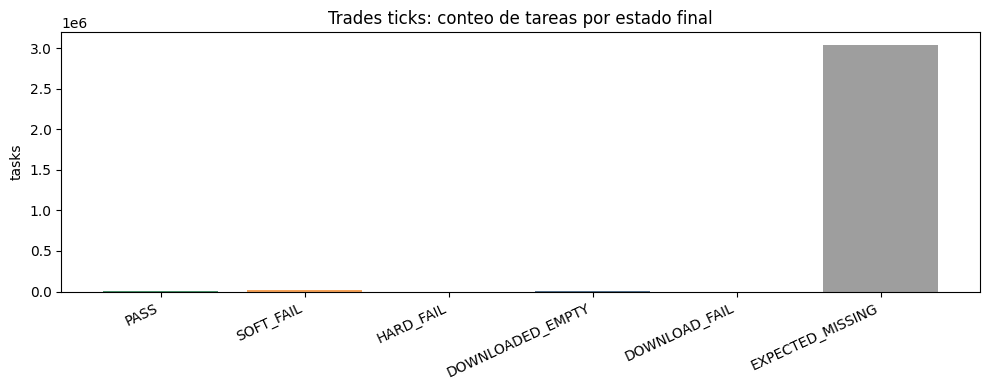

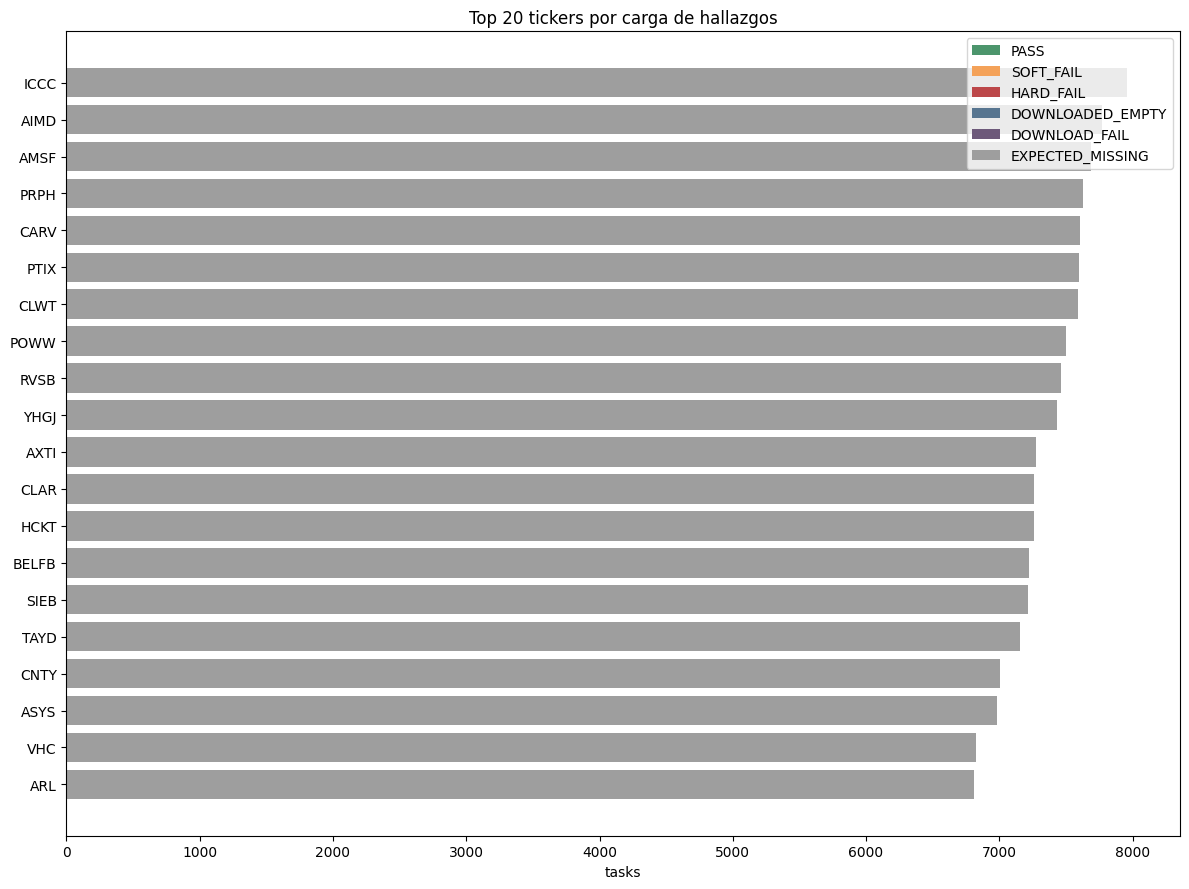

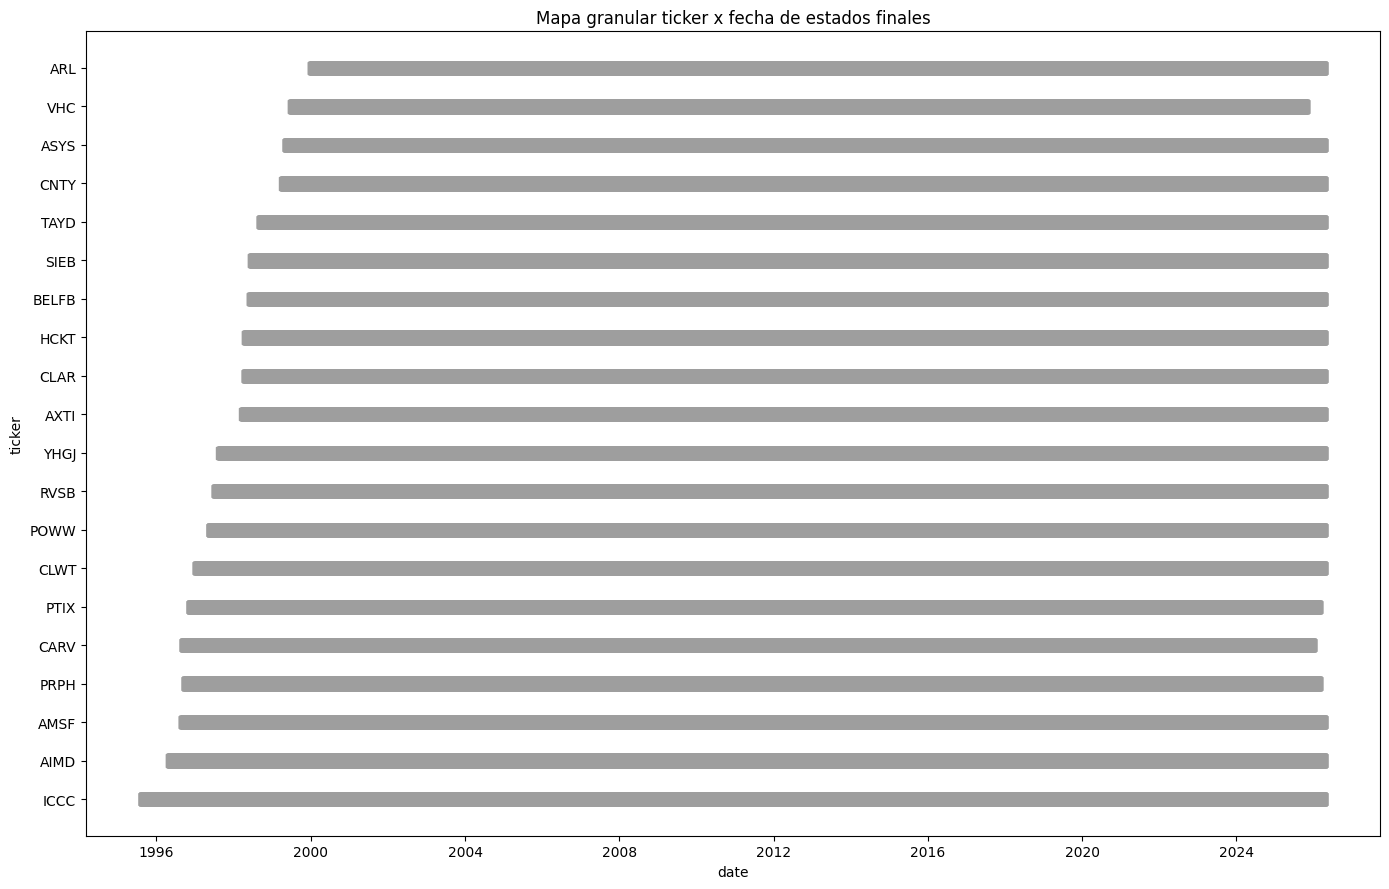

,ticker,empty_tasks,date_min,date_max
0,ACIC,2626,2012-12-10,2026-02-16
1,ABAT,2616,2013-10-17,2026-02-16
2,ABP,739,2022-01-13,2024-11-12
3,ACEL,636,2017-06-26,2020-07-03
4,ACET,445,2018-02-19,2026-02-16
5,ABEO,206,2014-11-04,2019-11-28
6,AAT,148,2011-01-11,2026-02-16
7,ACDC,136,2022-05-10,2023-09-04
8,ACRE,99,2012-04-18,2022-02-21
9,ACIU,93,2016-11-24,2026-02-16



=== TOP TICKERS POR PROBLEM RATIO / EMPTY RATIO ===


,ticker,PASS,SOFT_FAIL,HARD_FAIL,DOWNLOADED_EMPTY,DOWNLOAD_FAIL,EXPECTED_MISSING,expected_tasks,found_files,empty_ratio,problem_ratio
0,ACRS,0,0,0,0,0,2726,2726,0,0.0,1.0
1,ACRV,0,0,0,0,0,875,875,0,0.0,1.0
2,ACTG,0,0,0,0,0,2602,2602,0,0.0,1.0
3,ACTU,0,0,0,0,0,452,452,0,0.0,1.0
4,ACVA,0,0,0,0,0,1041,1041,0,0.0,1.0
5,ACXP,0,0,0,0,0,1233,1233,0,0.0,1.0
6,ADAM,0,0,0,0,0,3534,3534,0,0.0,1.0
7,ADCT,0,0,0,0,0,1685,1685,0,0.0,1.0
8,ADGM,0,0,0,0,0,422,422,0,0.0,1.0
9,ADIL,0,0,0,0,0,1469,1469,0,0.0,1.0



=== FECHAS CON MAYOR CONCENTRACION DE HALLAZGOS ===


,date,PASS,SOFT_FAIL,HARD_FAIL,DOWNLOADED_EMPTY,DOWNLOAD_FAIL,EXPECTED_MISSING,problem_tasks
7853,2025-10-20,1,9,0,0,0,1439,1448
7837,2025-09-26,1,8,0,0,0,1439,1447
7843,2025-10-06,0,9,0,0,0,1438,1447
7846,2025-10-09,1,8,0,0,0,1439,1447
7847,2025-10-10,1,8,0,1,0,1438,1447
7850,2025-10-15,0,9,0,1,0,1437,1447
7830,2025-09-17,1,8,0,0,0,1438,1446
7831,2025-09-18,1,8,0,0,0,1438,1446
7836,2025-09-25,1,8,0,0,0,1438,1446
7838,2025-09-29,2,7,0,0,0,1439,1446



=== EXPLORADOR GRANULAR POR TICKER / FECHA / ESTADO ===
Objetivo: abrir un caso especifico y ver si el problema es vacio real, fallo de descarga o anomalia intradia leve/fuerte.


In [18]:
TOP_N = 20
CONTEXT_DAYS = 20
MAX_PLOT_POINTS = 50000
FIGSIZE = (12, 4)

exec(SCRIPT_206.read_text(encoding='utf-8'), globals())


## Lectura Recomendada

1. Mira primero `run_summary.json` para separar `found_files` de `downloaded_empty_tasks`.
2. Usa el gr?fico de estados para ver si el run est? dominado por vac?os, soft fails o hard fails.
3. Usa el mapa `ticker x fecha` para detectar si el patr?n es persistente por ticker o puntual por fecha.
4. Abre el explorador y compara:
   - caso con parquet real
   - caso `DOWNLOADED_EMPTY`
   - caso `SOFT_FAIL`

La idea no es solo contar problemas, sino entender visualmente su naturaleza.


In [ ]:
from pathlib import Path
import pandas as pd

for name in ['task_status_detail.csv', 'status_by_ticker.csv', 'status_by_date.csv', 'task_causes_detail.csv']:
    p = OUT_DIR / name
    print(name, p.exists())
    if p.exists():
        df = pd.read_csv(p)
        print('rows:', len(df))
        display(df.head(20))


task_status_detail.csv True
